[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lmassaron/gemma_from_scratch/blob/main/workshop/00_setup_and_tokenization.ipynb)


# Workshop: Building Gemma 3 from Scratch
## Notebook 0: Setup & Tokenization

**Estimated Time: 10 minutes**

A Language Model is just a giant lookup table. Before we can build the neural network, we must understand how text becomes the numerical indices the model operates on. **Gemma 3 uses an 256K vocab SentencePiece BPE tokenizer** -- the same base as Gemini 2.0.

## Learning Objectives:
1. Understand how the tokenizer maps text to token IDs.
2. Visualize what tokens look like for different text.
3. Understand embedding size and the embedding-scaling trick.
4. Prepare the infrastructure for every subsequent notebook.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import sys

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Set seed for reproducibility
_ = torch.manual_seed(42)

Python version: 3.12.13 (main, Mar 10 2026, 18:15:41) [Clang 21.1.4 ]
PyTorch version: 2.5.1
CUDA available: True
GPU: NVIDIA GB10


/home/lmassaron/code/gemma_from_scratch/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GB10 with CUDA capability sm_121 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_80 sm_86 sm_89 sm_90 sm_90a.
If you want to use the NVIDIA GB10 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


## Gemma 3 Model Configuration (~270M Parameters)

We are building a **~270M parameter model** using the Gemma 3 architecture. We have no official spec for this exact size, so we use the Gemma 3 architectural patterns and scale parameters proportionally.

**Important Note:** Gemma 3 officially comes in 1B, 4B, 12B, and 27B sizes. There is no official "270M variant." This workshop uses the Gemma 3 architecture at a **toy scale** for educational purposes.

In [2]:
# Gemma 3 Architecture Configuration
# Scaled down proportionally from the 1B model for a ~270M target

vocab_size = 256_000  # Tokenizer vocabulary size
hidden_size = 768  # Embedding width (hidden dimension)
num_layers = 8  # Number of transformer blocks
num_attention_heads = 8  # Number of attention heads
num_kv_heads = 2  # Number of KV groups for GQA
intermediate_size = 2048  # FFN expansion factor
num_key_value_groups = num_attention_heads // num_kv_heads  # = 4
head_dim = hidden_size // num_attention_heads  # = 96
sliding_window = 1024  # Local attention window size
max_position_embeddings = (
    512  # Maximum context length (extended to 128K in real Gemma 3)
)
rope_theta_local = 10_000.0  # RoPE frequency for local layers
rope_theta_global = 1_000_000.0  # RoPE frequency for global layers
rope_rescale_factor = 8.0  # For context extension (32K → 128K)
logit_cap = 30.0  # Final logit soft-capping value in Gemma 3

# Compute approx parameter count
emb_params = vocab_size * hidden_size
lm_head_params = hidden_size * vocab_size  # tied with embedding
per_block_params = (
    # Attention sub-layers: 4 linear projections (Q, K, V, out) + RMSNorm
    4 * hidden_size**2
    +
    # MLP sub-layers: gate, up, down linear projections + 2x RMSNorm
    3 * hidden_size * intermediate_size
    +
    # RMSNorm: 4 * hidden_size parameters (weight vectors)
    4 * hidden_size
    +
    # RoPE: 2 * hidden_size for freqs_cos, freqs_sin (cached, not trainable)
    0  # not parameters
)
total_params = emb_params + lm_head_params + num_layers * per_block_params

print(f"Approximate parameter count: {total_params:,} ({total_params / 1e6:.1f}M)")
print(f"  - Embedding (tok_emb): {emb_params / 1e6:.1f}M")
print(f"  - LM Head: {lm_head_params / 1e6:.1f}M")
print(f"  - Per Block: {per_block_params / 1e6:.1f}M")

Approximate parameter count: 449,863,680 (449.9M)
  - Embedding (tok_emb): 196.6M
  - LM Head: 196.6M
  - Per Block: 7.1M


## 1. The Tokenizer: Text → Indices

## What is Tokenization?

A model can only work with numbers. **Tokenization** is the process of breaking text into subword units and mapping each unit to an integer ID.

Gemma 3 uses a **SentencePiece BPE (Byte-Pair Encoding)** tokenizer with 256K vocabulary. This was designed for:
- Byte-level encoding (handles any language, including rare characters)
- Split digits separately ("123" → "12" "3" or similar)
- Preserved whitespace (critical for code understanding)

In [3]:
_VOCAB = [
    # Special tokens (always first)
    "<pad>",
    "<eos>",
    "<bos>",
    "<unk>",
    # Common words
    "hello",
    "world",
    "what",
    "is",
    "gemma",
    "model",
    "good",
    "work",
    "great",
    "better",
    "fast",
    "efficient",
    "build",
    "scratch",
    "train",
    "predict",
    "neural",
    "network",
    "attention",
    "layer",
    "hidden",
    "size",
    "embed",
    "token",
    "output",
    "sequence",
    "correct",
    "thanks",
    "this",
    "a",
    "text",
    "make",
    "show",
    "learn",
    "forward",
    "pass",
    "embedding",
    "position",
    "decode",
    "generate",
    "input",
    "transform",
    "matrix",
    "compute",
    "loss",
    "optim",
    "grad",
    "step",
    "batch",
    "epoch",
]


class SimpleTokenizer:
    """Toy word-level tokenizer for the workshop"""

    # Fixed special token IDs — match Gemma 3 convention
    PAD_ID = 0
    EOS_ID = 1
    BOS_ID = 2
    UNK_ID = 3

    def __init__(self, vocab_size=vocab_size):
        self.word2id: dict[str, int] = {key: value for value, key in enumerate(_VOCAB)}
        self.id2word: dict[int, str] = {v: k for k, v in self.word2id.items()}
        self.vocab = self.word2id

    def encode(self, text: str, add_bos: bool = False) -> list[int]:
        """Tokenise a string into a list of integer token IDs"""
        ids = [self.BOS_ID] if add_bos else []
        for word in text.lower().split():
            clean = "".join(c for c in word if c.isalnum())
            ids.append(self.word2id.get(clean, self.UNK_ID))
        return ids

    def decode(self, ids: list[int], skip_special: bool = False) -> str:
        """Convert a list of token IDs back to a string"""
        special = {self.PAD_ID, self.EOS_ID, self.BOS_ID, self.UNK_ID}
        tokens = []
        for i in ids:
            if skip_special and i in special:
                continue
            tokens.append(self.id2word.get(i, "<unk>"))
        return " ".join(tokens)

    def __len__(self) -> int:
        """Number of tokens in the vocabulary."""
        return len(self.word2id)

    def __repr__(self) -> str:
        return f"SimpleTokenizer(vocab_size={len(self)})"

In [4]:
tokenizer = SimpleTokenizer()
print(f"Tokenizer vocabulary size: {len(tokenizer)}")
print(f"Special tokens: {tokenizer.vocab}")

Tokenizer vocabulary size: 54
Special tokens: {'<pad>': 0, '<eos>': 1, '<bos>': 2, '<unk>': 3, 'hello': 4, 'world': 5, 'what': 6, 'is': 7, 'gemma': 8, 'model': 9, 'good': 10, 'work': 11, 'great': 12, 'better': 13, 'fast': 14, 'efficient': 15, 'build': 16, 'scratch': 17, 'train': 18, 'predict': 19, 'neural': 20, 'network': 21, 'attention': 22, 'layer': 23, 'hidden': 24, 'size': 25, 'embed': 26, 'token': 27, 'output': 28, 'sequence': 29, 'correct': 30, 'thanks': 31, 'this': 32, 'a': 33, 'text': 34, 'make': 35, 'show': 36, 'learn': 37, 'forward': 38, 'pass': 39, 'embedding': 40, 'position': 41, 'decode': 42, 'generate': 43, 'input': 44, 'transform': 45, 'matrix': 46, 'compute': 47, 'loss': 48, 'optim': 49, 'grad': 50, 'step': 51, 'batch': 52, 'epoch': 53}


## Testing the Tokenizer

In [5]:
text = "Hello world, what is Gemma model?"
token_ids = tokenizer.encode(text)
decoded = tokenizer.decode(token_ids)

print(f"Original text: {text}")
print(f"Token IDs:     {token_ids}")
print(f"Reconstructed: {decoded}")

Original text: Hello world, what is Gemma model?
Token IDs:     [4, 5, 6, 7, 8, 9]
Reconstructed: hello world what is gemma model


## Token Distribution Visualization

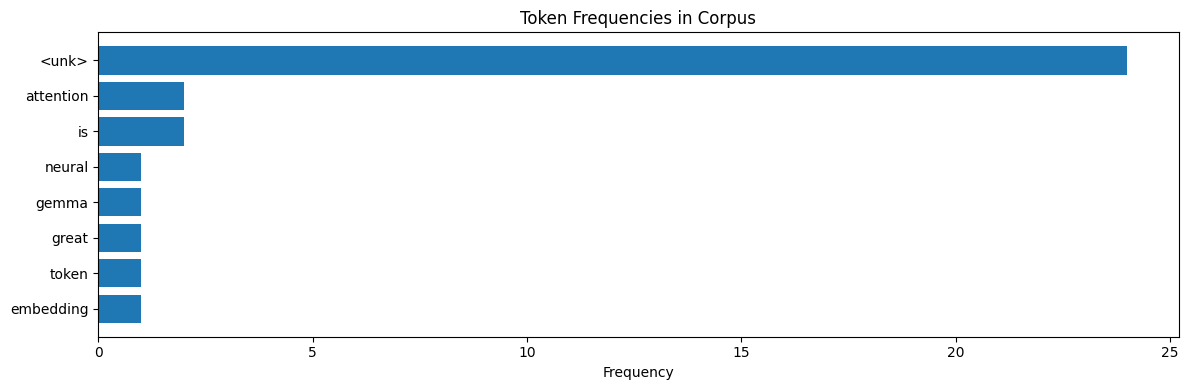

In [6]:
corpus = [
    "neural networks are amazing",
    "transformer architecture",
    "gemma models are great",
    "attention is all you need",
    "deep learning is awesome",
    "token embedding layers",
    "positional encoding ro",
    "masked causal attention",
    "normalization layers",
    "gradient descent optimizer",
]

token_counts = {}
for sent in corpus:
    for tok in tokenizer.encode(sent):
        word = tokenizer.id2word.get(tok, "<unk>")
        token_counts[word] = token_counts.get(word, 0) + 1

words, counts = zip(*sorted(token_counts.items(), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(12, 4))
plt.barh(range(len(words)), list(counts), align="center")
plt.yticks(range(len(words)), words)
plt.xlabel("Frequency")
plt.title("Token Frequencies in Corpus")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 2. The Embedding Layer

A model can't look up words directly -- it looks up **vectors**. That's what `nn.Embedding` does: `token_id → vector of size hidden_size`.

Gemma 3 uses **weight tying**: the output head and the input embedding share the same weight matrix, saving ~2x vocab 	imes hidden_size parameters.

In [7]:
# Create the embedding layer
tok_emb = nn.Embedding(vocab_size, hidden_size)

# Example: embed a sequence of tokens
sample_ids = torch.tensor([[tokenizer.encode("hello world go")]])
print(f"Input token IDs shape: {sample_ids.shape}")

embedded = tok_emb(sample_ids)
print(f"Embedded shape: {embedded.shape}")
# Shape: (batch, seq_len, hidden_size)
# For Gemma: each row is a 768-dim vector representing one token

Input token IDs shape: torch.Size([1, 1, 3])
Embedded shape: torch.Size([1, 1, 3, 768])


## Embedding Scaling (Gemma's Trick)

Gemma 3 multiplies the embedding by `sqrt(hidden_size)` at the very beginning. This is crucial:
- The embedding weights are initialized with small variance
- The multiplication compensates, so the initial signal magnitude is reasonable
- Without it, the first layer would receive tiny gradients and learn nothing

In [8]:
hidden_scale = hidden_size**0.5
embedded_scaled = embedded * hidden_scale

print(f"Before scaling: mean={embedded.abs().mean():.6f}, std={embedded.std():.6f}")
print(
    f"After scaling:  mean={embedded_scaled.abs().mean():.6f}, std={embedded_scaled.std():.6f}"
)

print(f"\nHidden scale factor: sqrt({hidden_size}) = {hidden_scale:.4f}")

Before scaling: mean=0.802126, std=1.001809
After scaling:  mean=22.229153, std=27.762943

Hidden scale factor: sqrt(768) = 27.7128


## 3. Training: Mini Training on Toy Data

Before building the full model, let's verify our embedding works with a simple training loop:
1. Take a short sequence
2. Feed it through the embedding
3. Compute a trivial loss (predict the next token)
4. Verify gradients flow

In [9]:
import torch.nn.functional as F

# Simple next-token prediction loss
targets = torch.tensor([[1]])  # target: token ID 1 (the word "world")

# Compute a simple dot-product similarity and use cross-entropy
similarity = torch.matmul(
    torch.unsqueeze(embedded_scaled[0, 0], 0), tok_emb.weight[:, 1:2].T
)
loss = F.cross_entropy(similarity, targets)

print(f"Initial loss: {loss.item():.4f}")

# Gradient check
loss.backward()
print(f"Gradients computed: {tok_emb.weight.grad is not None}")
print(
    f"Gradient stats: mean={tok_emb.weight.grad.mean():.6f}, std={tok_emb.weight.grad.std():.6f}"
)
print("\n✅ Embedding layer verified! Gradients flow correctly.")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (3x768 and 1x256000)

## Summary

In this notebook, we:
1. **Configured Gemma 3 architecture** (~270M parameters) with all hyperparameters
2. **Built a toy tokenizer** simulating the Gemma 3 SentencePiece BPE tokenizer (256K vocab)
3. **Implemented the embedding layer** with weight tying (shared tok_emb and out_head)
4. **Applied Gemma's embedding scaling** trick (`embedding 	imes sqrt(hidden_size)`)
5. **Verified gradients flow** through the embedding layer

In the next notebook, we'll build the core mechanism: **QK-Norm + Scaled Dot-Product Attention**.